## KNN Baseline

### Notebook Configuration && Imports


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import mlflow
from mlflow.data.pandas_dataset import from_pandas
import optuna

from chesswinnerprediction.baseline.models.custom_knn import CustomKNNClassifier
from chesswinnerprediction.baseline.constants import BASELINE_RANDOM_STATE
from chesswinnerprediction.constants import DRAW_STR, BLACK_WIN_STR, WHITE_WIN_STR
from chesswinnerprediction.baseline.utils import (
    estimate_baseline_model,
    load_train_valid_test,
    setup_mlflow,
)

### Setup MLFlow

In [3]:
experiment_id = setup_mlflow(experiment_name="Optuna KNN")

### Load Data

In [4]:
X_train, y_train, X_valid, y_valid, X_test, y_test = load_train_valid_test()

### Optuna Objective 

In [5]:
def get_model(trial: optuna.Trial):
    wins_constant = trial.suggest_float("wins_constant", 1, 2)
    draws_constant = trial.suggest_float("draws_constant", 1, 2)

    n_neighbors = trial.suggest_int("n_neighbors", 30, 150)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])

    class_weight = {
        DRAW_STR: draws_constant,
        BLACK_WIN_STR: wins_constant,
        WHITE_WIN_STR: wins_constant,
    }

    knn_model = CustomKNNClassifier(
        random_state=BASELINE_RANDOM_STATE,
        n_neighbors=n_neighbors,
        weights=weights,
        class_weight=class_weight,
        n_jobs=-1,
    )
    return knn_model


def objective(trial: optuna.Trial):
    knn_model = get_model(trial)
    knn_model.fit(X_train, y_train)

    score = knn_model.score(X_valid, y_valid, use_subset=False)

    with mlflow.start_run(nested=True, run_name=f"KNN_Trial_{trial.number}"):
        mlflow.log_params(trial.params)
        mlflow.log_metric("balanced_accuracy_X_valid", score)

    return score

## Optuna Tuning

In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [7]:
with mlflow.start_run(run_name="KNN_Tuning"):
    study = optuna.create_study(direction="maximize", study_name="KNN Tuning")
    study.optimize(objective, n_trials=26, n_jobs=-1, show_progress_bar=True)

    best_params = study.best_params
    best_knn = get_model(study.best_trial)
    best_knn.fit(X_train, y_train)

    best_score = best_knn.score(X_test, y_test, use_subset=False)
    mlflow.log_metric("balanced_accuracy_X_test", best_score)

    dataset = from_pandas(X_test)
    mlflow.log_input(dataset, "X_test")

  0%|          | 0/26 [00:00<?, ?it/s]

## Best Model

Log Loss on test data: 1.042
Balanced Accuracy on test data: 44.66%


                                                Classification Report
                         Train Report                                      Test Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.42      0.49     75369              0.58      0.41      0.48     31936
         1-0       0.60      0.41      0.48     78653              0.59      0.40      0.48     33134
     1/2-1/2       0.05      0.57      0.08      4115              0.04      0.53      0.07      1615
    accuracy                           0.42    158137                                  0.41     66685
   macro avg       0.41      0.46      0.35    158137              0.40      0.45      0.34     66685
weighted avg       0.58      0.42      0.48    158137              0.57      0.41      0.47     66685
       


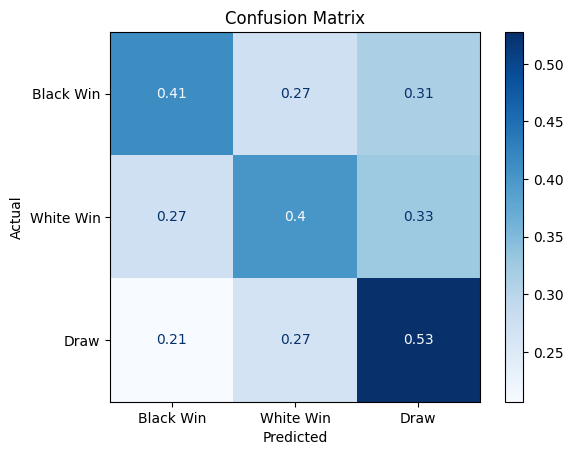

In [9]:
estimate_baseline_model(
    best_knn, None, X_train, y_train, X_test, y_test, report_title_2="Test Report"
)

## Summary

Overall, the KNN model performed reasonably well, achieving a balanced accuracy of 44.66% on the test set.  
The result is highly dependent on the number of samples in each class, so you must use a large number of `n_trials` for parameter tuning.  
With proper tuning, I believe the results could be significantly improved.